# install

In [ ]:
# Cài đặt hoặc nâng cấp vnstock
!pip install -U vnstock pykalman

In [ ]:
from vnstock import Quote
quote = Quote(symbol='ACB', source='KBS')

# Cell 1: Load dữ liệu CTG - STB

In [ ]:
from vnstock import Quote
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

SYMBOLS = ["CTG", "STB"]
START, END = "2024-01-01", "2025-12-31"

raw = {}
for sym in SYMBOLS:
    df = Quote(symbol=sym, source="KBS").history(start=START, end=END, interval="d")
    raw[sym] = df.set_index("time")[["close"]].sort_index()

price_df = pd.DataFrame({sym: d["close"] for sym, d in raw.items()}).dropna()

print("Price shape:", price_df.shape)
print("Date range:", price_df.index.min(), "→", price_df.index.max())
price_df.head()

Price shape: (499, 2)
Date range: 2024-01-02 07:00:00 → 2025-12-31 07:00:00


,CTG,STB
time,,
2024-01-02 07:00:00,18.38,27.75
2024-01-03 07:00:00,18.65,28.50
2024-01-04 07:00:00,19.33,28.60
2024-01-05 07:00:00,19.60,29.30
2024-01-08 07:00:00,19.97,29.20


# Cell 2: Baseline - Tính beta bằng ols


In [ ]:
# Cell 2: Baseline — Static OLS hedge ratio (tương tự notebook trước)
y = price_df["CTG"]
x = price_df["STB"]
x_const = sm.add_constant(x)

ols_result = sm.OLS(y, x_const).fit()
alpha_static, beta_static = ols_result.params

spread_static = y - (alpha_static + beta_static * x)

adf_static = adfuller(spread_static)

print(f"Static OLS: CTG = {alpha_static:.4f} + {beta_static:.4f} * STB + spread")
print(f"R-squared: {ols_result.rsquared:.4f}")
print(f"\nADF test — Static spread:")
print(f"  ADF stat: {adf_static[0]:.4f}")
print(f"  p-value:  {adf_static[1]:.6f}")
print(f"  {'✅ Stationary' if adf_static[1] < 0.05 else '❌ Non-stationary'}")

Static OLS: CTG = 8.7545 + 0.4595 * STB + spread
R-squared: 0.9264

ADF test — Static spread:
  ADF stat: -4.1649
  p-value:  0.000755
  ✅ Stationary


OLS có R2 cao

Spread dừng

=> Đúng như kỳ vọng

# Cell 3: Dùng Kalman Filter để tạo beta động

In [ ]:
# Cell 3: Kalman filter — Dynamic hedge ratio (pykalman)
from pykalman import KalmanFilter

# State space model:
# Observation: y_t = beta_t * x_t + alpha_t + noise
# State: [beta_t, alpha_t] đi theo random walk (thay đổi chậm theo thời gian)

# Observation matrix: mỗi thời điểm t, ma trận quan sát là [x_t, 1]
obs_mat = np.vstack([x.values, np.ones(len(x))]).T[:, np.newaxis, :]  # shape (T, 1, 2)

# delta điều khiển tốc độ thay đổi của beta — delta nhỏ = beta mượt/ổn định hơn
# delta lớn = beta phản ứng nhanh với data mới (dễ bị noisy)
delta = 1e-4
trans_cov = delta / (1 - delta) * np.eye(2)

kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=[0, 0],
    initial_state_covariance=np.ones((2, 2)),
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,
    observation_covariance=1.0,
    transition_covariance=trans_cov,
)

state_means, state_covs = kf.filter(y.values)

beta_dynamic = pd.Series(state_means[:, 0], index=price_df.index, name="beta_t")
alpha_dynamic = pd.Series(state_means[:, 1], index=price_df.index, name="alpha_t")

print("Dynamic beta (Kalman) — 5 giá trị đầu và cuối:")
print(beta_dynamic.head())
print("...")
print(beta_dynamic.tail())

print(f"\nSo sánh với static beta (OLS): {beta_static:.4f}")
print(f"Dynamic beta — mean: {beta_dynamic.mean():.4f}, std: {beta_dynamic.std():.4f}")
print(f"Dynamic beta — min: {beta_dynamic.min():.4f}, max: {beta_dynamic.max():.4f}")

Dynamic beta (Kalman) — 5 giá trị đầu và cuối:
time
2024-01-02 07:00:00    0.638532
2024-01-03 07:00:00    0.635162
2024-01-04 07:00:00    0.642024
2024-01-05 07:00:00    0.643636
2024-01-08 07:00:00    0.648858
Name: beta_t, dtype: float64
...
time
2025-12-25 07:00:00    0.609281
2025-12-26 07:00:00    0.600865
2025-12-29 07:00:00    0.585828
2025-12-30 07:00:00    0.579930
2025-12-31 07:00:00    0.586063
Name: beta_t, dtype: float64

So sánh với static beta (OLS): 0.4595
Dynamic beta — mean: 0.6803, std: 0.0568
Dynamic beta — min: 0.5718, max: 0.7897


Dynamics beta cao hơn beta tĩnh được tính từ OLS khá nhiều

Min cao hơn beta từ OLS khoảng 20%

Mean cao hơn beta từ OLS khoảng 48%

Max cao hơn beta từ OLS đến hơn 70%

Điều này có thể đến từ việc regime thị trường thay đổi, dẫn đến beta phải chạy theo để phù hợp

# Cell 4:Plot

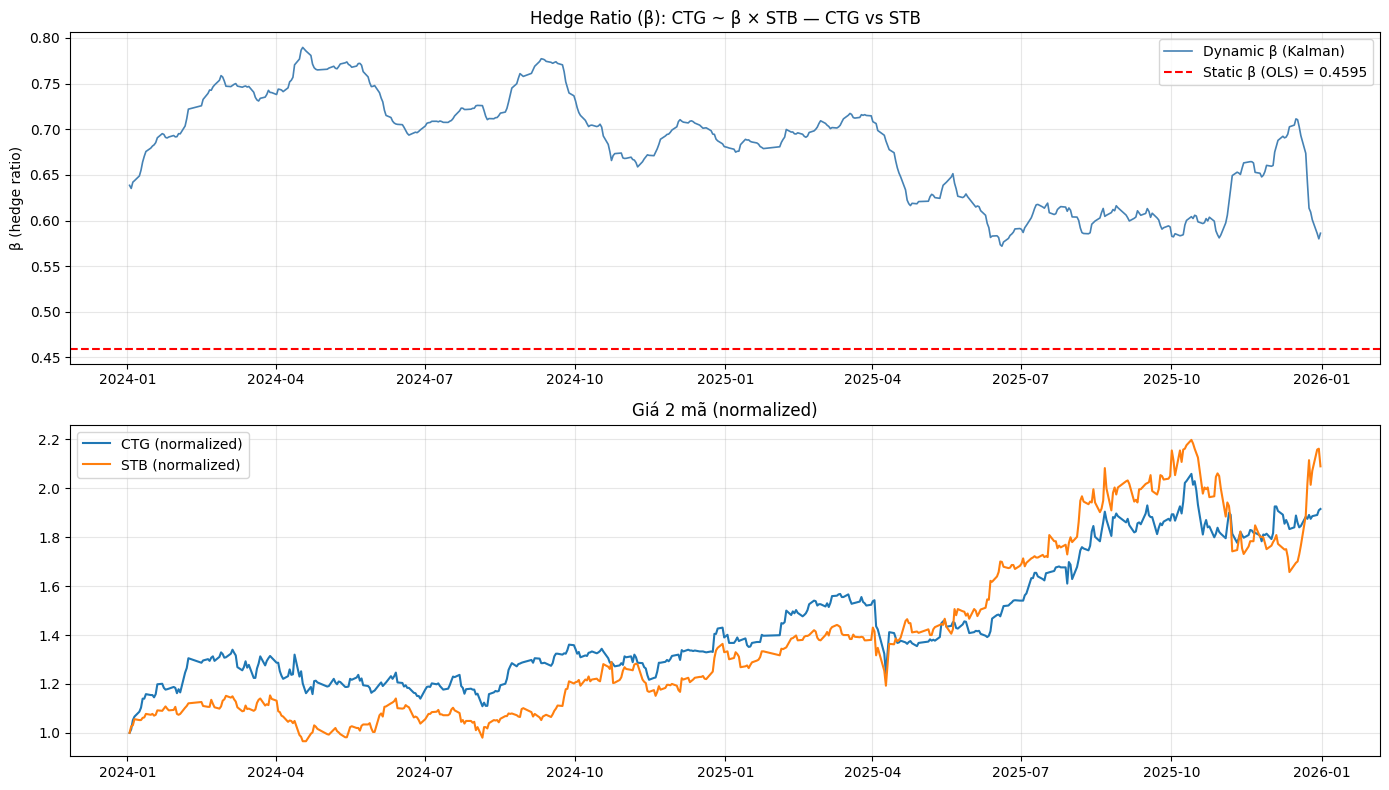

ĐÁNH GIÁ: Beta có thay đổi đáng kể không?
Range (max - min):        0.2179
Coefficient of variation: 0.0835  (std/|mean|)

📌 Beta thay đổi NHẸ (CV 5-15%) — có drift nhưng không quá mạnh.


In [ ]:
#Cell 4: Plot beta theo thời gian
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(beta_dynamic.index, beta_dynamic.values, label="Dynamic β (Kalman)", color="steelblue", linewidth=1.2)
ax1.axhline(beta_static, color="red", linestyle="--", label=f"Static β (OLS) = {beta_static:.4f}")
ax1.set_title(f"Hedge Ratio (β): CTG ~ β × STB — {SYMBOLS[0]} vs {SYMBOLS[1]}")
ax1.set_ylabel("β (hedge ratio)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(price_df.index, price_df["CTG"] / price_df["CTG"].iloc[0], label="CTG (normalized)")
ax2.plot(price_df.index, price_df["STB"] / price_df["STB"].iloc[0], label="STB (normalized)")
ax2.set_title("Giá 2 mã (normalized)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Đánh giá định lượng: beta có "thay đổi đáng kể" không?
beta_range = beta_dynamic.max() - beta_dynamic.min()
beta_cv = beta_dynamic.std() / abs(beta_dynamic.mean())  # coefficient of variation

print(f"{'='*60}")
print("ĐÁNH GIÁ: Beta có thay đổi đáng kể không?")
print(f"{'='*60}")
print(f"Range (max - min):        {beta_range:.4f}")
print(f"Coefficient of variation: {beta_cv:.4f}  (std/|mean|)")

if beta_cv < 0.05:
    print("\n📌 Beta GẦN NHƯ KHÔNG ĐỔI (CV < 5%) — đây là phát hiện hợp lệ:")
    print("   quan hệ hedge ratio giữa 2 mã ổn định qua thời gian, static OLS")
    print("   là mô hình đã đủ tốt, Kalman không mang lại lợi thế lớn cho cặp này.")
elif beta_cv < 0.15:
    print("\n📌 Beta thay đổi NHẸ (CV 5-15%) — có drift nhưng không quá mạnh.")
else:
    print("\n📌 Beta thay đổi ĐÁNG KỂ (CV > 15%) — dynamic hedge ratio")
    print("   có khả năng cải thiện rõ so với static OLS.")

Beta thay đổi khoản 8%, ko quá mạnh, nhưng điểm đáng chú ý là lệch rất mạnh khỏi beta từ OLS, tức là có R rất nhỏ (nhiễu không nhiều, phù hợp với cổ phiếu ngân hàng) => Beta này phụ thuộc nhiều hơn vào thông tin mới

# Cell 5: so sánh 2 spread (kiểm định bằng adf)

SO SÁNH ADF: Static OLS spread vs Dynamic Kalman spread
Static  — ADF stat: -4.1649, p-value: 0.000755, Stationary ✅
Dynamic — ADF stat: -10.7815, p-value: 0.000000, Stationary ✅

🏆 Spread 'sạch' hơn (p-value thấp hơn): Dynamic (Kalman)

Mức độ 'trôi' của mean (std của rolling-mean 20 ngày, càng thấp càng ổn định quanh 0):
  Static:  1.0191
  Dynamic: 0.1587


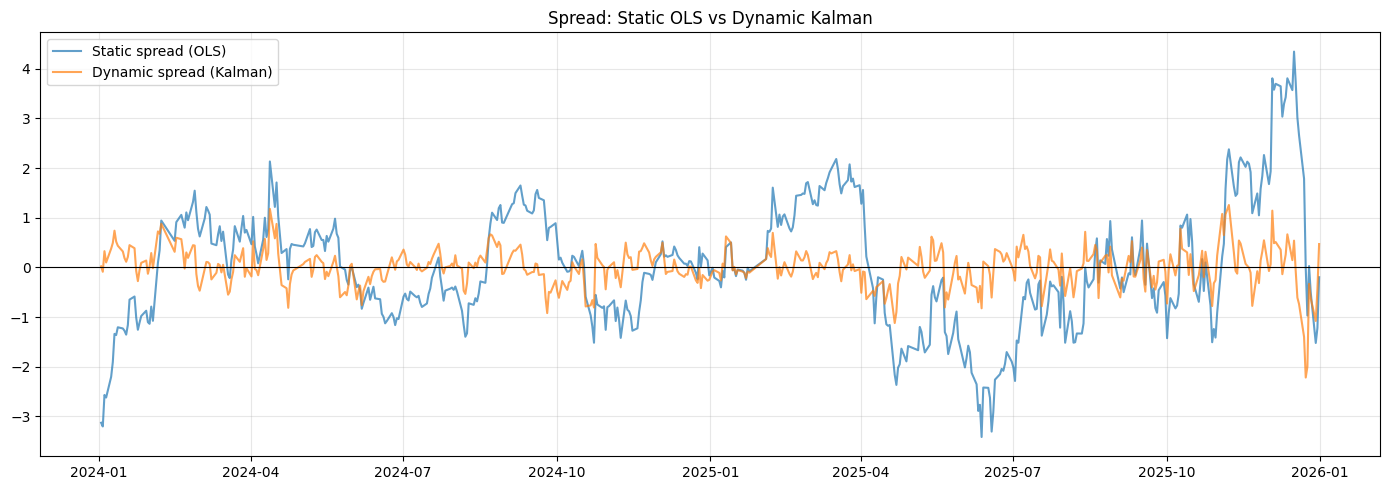

In [ ]:
# Cell 5: Spread mới (dynamic) vs spread cũ (static) — so ADF
spread_dynamic = y - (alpha_dynamic + beta_dynamic * x)

adf_dynamic = adfuller(spread_dynamic)

print(f"{'='*60}")
print("SO SÁNH ADF: Static OLS spread vs Dynamic Kalman spread")
print(f"{'='*60}")
print(f"Static  — ADF stat: {adf_static[0]:.4f}, p-value: {adf_static[1]:.6f}, {'Stationary ✅' if adf_static[1] < 0.05 else 'Non-stationary ❌'}")
print(f"Dynamic — ADF stat: {adf_dynamic[0]:.4f}, p-value: {adf_dynamic[1]:.6f}, {'Stationary ✅' if adf_dynamic[1] < 0.05 else 'Non-stationary ❌'}")

winner = "Dynamic (Kalman)" if adf_dynamic[1] < adf_static[1] else "Static (OLS)"
print(f"\n🏆 Spread 'sạch' hơn (p-value thấp hơn): {winner}")

# So sánh mức độ lệch mean kéo dài — dùng std của rolling mean 20 ngày làm proxy
static_drift = spread_static.rolling(20).mean().std()
dynamic_drift = spread_dynamic.rolling(20).mean().std()

print(f"\nMức độ 'trôi' của mean (std của rolling-mean 20 ngày, càng thấp càng ổn định quanh 0):")
print(f"  Static:  {static_drift:.4f}")
print(f"  Dynamic: {dynamic_drift:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spread_static.index, spread_static.values, label="Static spread (OLS)", alpha=0.7)
ax.plot(spread_dynamic.index, spread_dynamic.values, label="Dynamic spread (Kalman)", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Spread: Static OLS vs Dynamic Kalman")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cả 2 đều dừng sau khi kiểm định ADF => Phù hợp với mô hình

Beta động có độ lệch chuẩn thấp => chứng tỏ việc dùng beta động là phù hợp hơn, trong khi beta tĩnh lại trôi rất mạnh

# Cell 6: Backtest nhanh (chưa có OOS)

BACKTEST NHANH (chưa tính transaction cost)
Static (OLS)   — Sharpe: 0.873, Cumulative P&L: 8.00, N trades days: 273
Dynamic (Kalman) — Sharpe: 3.304, Cumulative P&L: 22.55, N trades days: 186

🏆 Sharpe cao hơn: Dynamic (Kalman)


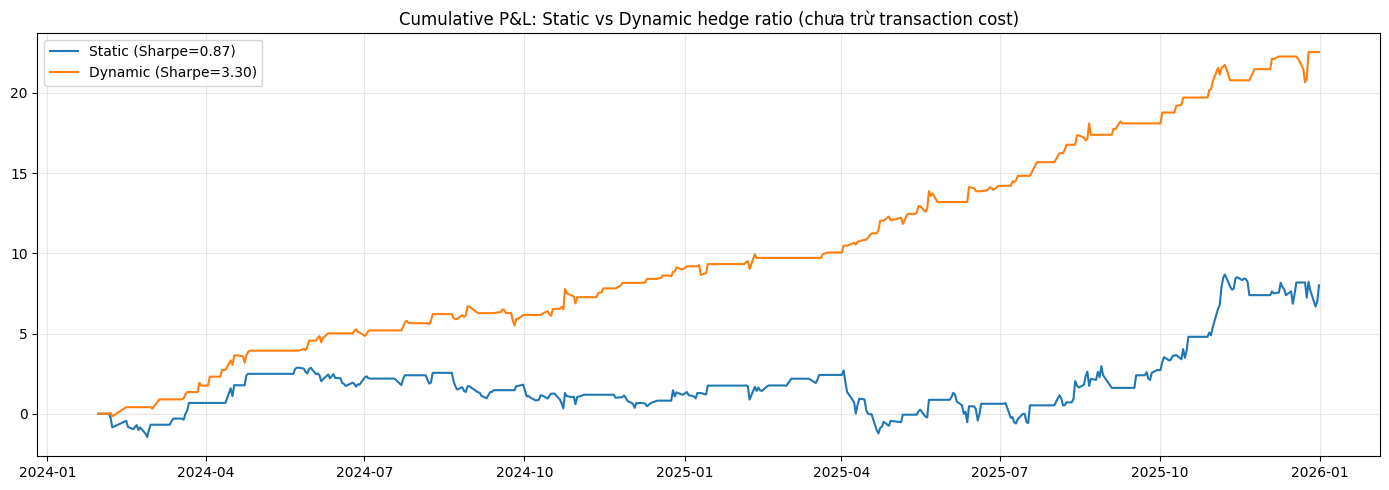


⚠️  Lưu ý: đây là backtest sơ bộ — chưa tính transaction cost, slippage,
   chưa test out-of-sample. Kết quả chỉ mang tính tham khảo, để dành Ngày 13
   cho backtest đầy đủ (cost-aware) trước khi kết luận chiến lược nào thực sự tốt hơn.


In [ ]:
# Cell 6: Backtest nhanh — entry/exit theo z-score, so Sharpe (chưa tính transaction cost)
def zscore_backtest(spread: pd.Series, entry_z: float = 1.5, exit_z: float = 0.5) -> pd.Series:
    """
    Backtest đơn giản:
    - Long spread khi z-score < -entry_z (spread quá thấp, kỳ vọng tăng)
    - Short spread khi z-score > +entry_z (spread quá cao, kỳ vọng giảm)
    - Đóng vị thế khi |z-score| < exit_z
    Trả về daily return của chiến lược (chưa trừ transaction cost).
    """
    z = (spread - spread.rolling(20).mean()) / spread.rolling(20).std()
    z = z.dropna()

    position = pd.Series(0, index=z.index)
    pos = 0
    for t in z.index:
        if pos == 0:
            if z[t] < -entry_z:
                pos = 1   # long spread
            elif z[t] > entry_z:
                pos = -1  # short spread
        else:
            if abs(z[t]) < exit_z:
                pos = 0
        position[t] = pos

    spread_ret = spread.diff().reindex(position.index)
    strat_ret = position.shift(1) * spread_ret  # dùng position hôm trước để tránh look-ahead
    return strat_ret.dropna()

def sharpe_ratio(returns: pd.Series, periods_per_year: int = 252) -> float:
    if returns.std() == 0:
        return np.nan
    return returns.mean() / returns.std() * np.sqrt(periods_per_year)

ret_static = zscore_backtest(spread_static)
ret_dynamic = zscore_backtest(spread_dynamic)

sharpe_static = sharpe_ratio(ret_static)
sharpe_dynamic = sharpe_ratio(ret_dynamic)

print(f"{'='*60}")
print("BACKTEST NHANH (chưa tính transaction cost)")
print(f"{'='*60}")
print(f"Static (OLS)   — Sharpe: {sharpe_static:.3f}, Cumulative P&L: {ret_static.sum():.2f}, N trades days: {(ret_static != 0).sum()}")
print(f"Dynamic (Kalman) — Sharpe: {sharpe_dynamic:.3f}, Cumulative P&L: {ret_dynamic.sum():.2f}, N trades days: {(ret_dynamic != 0).sum()}")

winner_sharpe = "Dynamic (Kalman)" if sharpe_dynamic > sharpe_static else "Static (OLS)"
print(f"\n🏆 Sharpe cao hơn: {winner_sharpe}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ret_static.cumsum().index, ret_static.cumsum().values, label=f"Static (Sharpe={sharpe_static:.2f})")
ax.plot(ret_dynamic.cumsum().index, ret_dynamic.cumsum().values, label=f"Dynamic (Sharpe={sharpe_dynamic:.2f})")
ax.set_title("Cumulative P&L: Static vs Dynamic hedge ratio (chưa trừ transaction cost)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️  Lưu ý: đây là backtest sơ bộ — chưa tính transaction cost, slippage,")
print("   chưa test out-of-sample. Kết quả chỉ mang tính tham khảo, để dành Ngày 13")
print("   cho backtest đầy đủ (cost-aware) trước khi kết luận chiến lược nào thực sự tốt hơn.")

Sharpe của dynamic beta cao hơn gần 4 lần so với beta tĩnh từ OLS, số phiên giao dịch thấp hơn đáng kể (gần 100 phiên) nhưng lợi nhuận lũy kế lại tốt hơn phiên bản sử dụng beta tĩnh nhiều

Tuy vậy, con số này có thể chưa chính xác tuyệt đối do chưa tính đến phí giao dịch, và cặp cổ phiếu cũng đã được chọn lựa từ trước, cho nên có thể cần cân nhắc đến DSR hoặc các kiểm định multiple testing

# Cell 7: Mở rộng dữ liệu để có OOS

In [ ]:
#Cell 7: Load lại dữ liệu, mở rộng đến 31/07/2026 để có phần OOS
END_OOS = "2026-07-31"

raw_full = {}
for sym in SYMBOLS:
    df = Quote(symbol=sym, source="KBS").history(start=START, end=END_OOS, interval="d")
    raw_full[sym] = df.set_index("time")[["close"]].sort_index()

price_full = pd.DataFrame({sym: d["close"] for sym, d in raw_full.items()}).dropna()

IS_CUTOFF = "2025-12-31"
price_is = price_full[price_full.index <= IS_CUTOFF]   # in-sample: giống notebook cũ
price_oos = price_full[price_full.index > IS_CUTOFF]    # out-of-sample: 2026

print(f"In-sample:  {price_is.index.min()} → {price_is.index.max()}  ({len(price_is)} obs)")
print(f"OOS:        {price_oos.index.min()} → {price_oos.index.max()}  ({len(price_oos)} obs)")

y_oos, x_oos = price_oos["CTG"], price_oos["STB"]

In-sample:  2024-01-02 07:00:00 → 2025-12-30 07:00:00  (498 obs)
OOS:        2025-12-31 07:00:00 → 2026-07-31 07:00:00  (143 obs)


# Cell 8: Kiểm tra look ahead bias

In [62]:
# Cell 8: Kiểm tra beta để chắc chắn ko có look ahead bias

# Static hedge ratio giữ nguyên alpha_static, beta_static từ Cell 2 (fit trên in-sample)
# => đây mới đúng nghĩa OOS: không cho model "nhìn thấy" dữ liệu 2026 khi ước lượng tham số
spread_static_oos = y_oos - (alpha_static + beta_static * x_oos)

# Kiểm tra index phải khớp hoàn toàn với price_oos
assert spread_static_oos.index.equals(price_oos.index), \
    "Index của spread_static_oos không khớp với price_oos.index"

print(f"Static β (giữ nguyên từ in-sample): {beta_static:.4f}")
print(f"Static spread OOS — mean: {spread_static_oos.mean():.4f}, std: {spread_static_oos.std():.4f}")
print(f"Static OOS: {spread_static_oos.index.min()} → {spread_static_oos.index.max()} ({len(spread_static_oos)} obs)")

Static β (giữ nguyên từ in-sample): 0.4595
Static spread OOS — mean: -4.5839, std: 4.5001
Static OOS: 2025-12-31 07:00:00 → 2026-07-31 07:00:00 (143 obs)


# Cell 9: Kiểm tra trước khi backtest

In [ ]:
# Cell 9: Kiểm tra, tính toán trước khi backtest

# Lấy state cuối cùng (mean + covariance) của Kalman filter từ in-sample (Cell 3)
# rồi filter tiếp cho OOS — KHÔNG re-fit từ đầu, giữ đúng tinh thần online/adaptive filter
last_state_mean = state_means[-1]
last_state_cov = state_covs[-1]

obs_mat_oos = np.vstack([x_oos.values, np.ones(len(x_oos))]).T[:, np.newaxis, :]

kf_oos = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat_oos,
    observation_covariance=1.0,
    transition_covariance=trans_cov,
    initial_state_mean=last_state_mean,
    initial_state_covariance=last_state_cov,
)

state_means_oos, state_covs_oos = kf_oos.filter(y_oos.values)

beta_dynamic_oos = pd.Series(state_means_oos[:, 0], index=price_oos.index)
alpha_dynamic_oos = pd.Series(state_means_oos[:, 1], index=price_oos.index)

spread_dynamic_oos = y_oos - (alpha_dynamic_oos + beta_dynamic_oos * x_oos)

# Kiểm tra index phải khớp hoàn toàn với price_oos
assert spread_dynamic_oos.index.equals(price_oos.index), \
    "Index của spread_dynamic_oos không khớp với price_oos.index"

print(f"Dynamic β OOS — mean: {beta_dynamic_oos.mean():.4f}, std: {beta_dynamic_oos.std():.4f}")
print(f"(so với β cuối in-sample: {beta_dynamic.iloc[-1]:.4f})")
print(f"Dynamic OOS: {spread_dynamic_oos.index.min()} → {spread_dynamic_oos.index.max()} ({len(spread_dynamic_oos)} obs)")

Dynamic β OOS — mean: 0.5164, std: 0.0741
(so với β cuối in-sample: 0.5861)
Dynamic OOS: 2025-12-31 07:00:00 → 2026-07-31 07:00:00 (143 obs)


# Cell 10: Backtest trên OOS

OUT-OF-SAMPLE BACKTEST (2025-12-31 → 2026-07-31)
Static (OLS)     — Sharpe: 2.423, Cumulative P&L: 13.31, Trade days: 70
Dynamic (Kalman) — Sharpe: 4.082, Cumulative P&L: 12.44, Trade days: 38

🏆 Sharpe cao hơn trên OOS: Dynamic (Kalman)

SO SÁNH IN-SAMPLE vs OUT-OF-SAMPLE
Model                  Sharpe IS    Sharpe OOS
Static (OLS)               0.873         2.423
Dynamic (Kalman)           3.304         4.082


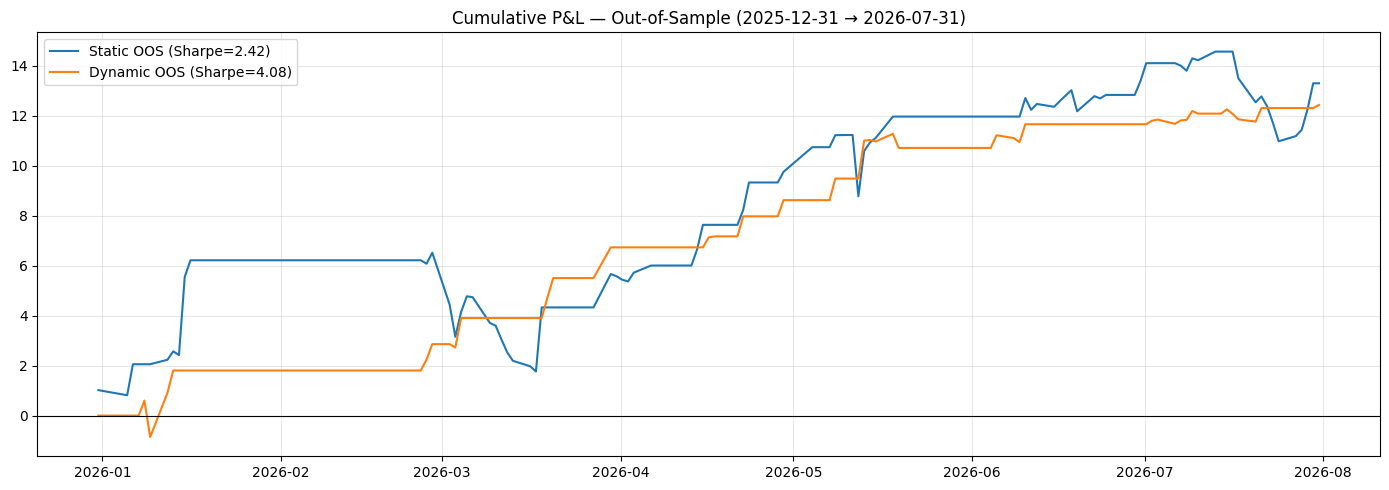


⚠️  Vẫn chưa tính transaction cost/slippage (để dành Ngày 13) — con số Sharpe
   ở đây là upper bound lý tưởng, thực tế sẽ thấp hơn sau khi trừ chi phí giao dịch.


In [ ]:
# Cell 10: Backtest trên OOS
def backtest_oos(spread_full: pd.Series, oos_index: pd.DatetimeIndex,
                  entry_z: float = 1.5, exit_z: float = 0.5) -> pd.Series:
    """
    spread_full: spread đã nối (20 obs cuối in-sample + toàn bộ OOS) để rolling(20) không bị NaN
                 ngay từ ngày đầu OOS.
    Trả về strategy return CHỈ trong khoảng OOS.
    """

    # FIX 1: đảm bảo không có duplicate timestamp
    spread_full = spread_full[
        ~spread_full.index.duplicated(keep="last")
    ].sort_index()

    z = (spread_full - spread_full.rolling(20).mean()) / spread_full.rolling(20).std()
    z = z.dropna()

    position = pd.Series(0, index=z.index)
    pos = 0

    # FIX 2: dùng iloc để z[t] luôn trả về scalar,
    # tránh lỗi "truth value of a Series is ambiguous"
    for i in range(len(z)):
        z_t = z.iloc[i]

        if pos == 0:
            if z_t < -entry_z:
                pos = 1
            elif z_t > entry_z:
                pos = -1
        else:
            if abs(z_t) < exit_z:
                pos = 0

        position.iloc[i] = pos

    spread_ret = spread_full.diff().reindex(position.index)
    strat_ret = position.shift(1) * spread_ret

    # FIX 3: chỉ lấy đúng OOS
    return strat_ret.reindex(oos_index).dropna()


# Nối 20 obs cuối in-sample vào đầu OOS để rolling window có đủ warm-up ngay ngày đầu OOS
# FIX 4: chỉ lấy observations STRICTLY trước ngày đầu OOS,
# tránh duplicate tại boundary IS/OOS
oos_start = price_oos.index.min()

static_warmup = spread_static.loc[
    spread_static.index < oos_start
].tail(20)

dynamic_warmup = spread_dynamic.loc[
    spread_dynamic.index < oos_start
].tail(20)

spread_static_full = pd.concat([
    static_warmup,
    spread_static_oos
])

spread_dynamic_full = pd.concat([
    dynamic_warmup,
    spread_dynamic_oos
])

# FIX 5: kiểm tra không còn duplicate sau khi nối
assert not spread_static_full.index.duplicated().any(), \
    "Static spread vẫn còn duplicate timestamp"

assert not spread_dynamic_full.index.duplicated().any(), \
    "Dynamic spread vẫn còn duplicate timestamp"


ret_static_oos = backtest_oos(spread_static_full, price_oos.index)
ret_dynamic_oos = backtest_oos(spread_dynamic_full, price_oos.index)

sharpe_static_oos = sharpe_ratio(ret_static_oos)
sharpe_dynamic_oos = sharpe_ratio(ret_dynamic_oos)

print(f"{'='*60}")
print(f"OUT-OF-SAMPLE BACKTEST ({price_oos.index.min().date()} → {price_oos.index.max().date()})")
print(f"{'='*60}")
print(f"Static (OLS)     — Sharpe: {sharpe_static_oos:.3f}, Cumulative P&L: {ret_static_oos.sum():.2f}, Trade days: {(ret_static_oos != 0).sum()}")
print(f"Dynamic (Kalman) — Sharpe: {sharpe_dynamic_oos:.3f}, Cumulative P&L: {ret_dynamic_oos.sum():.2f}, Trade days: {(ret_dynamic_oos != 0).sum()}")

winner_oos = "Dynamic (Kalman)" if sharpe_dynamic_oos > sharpe_static_oos else "Static (OLS)"
print(f"\n🏆 Sharpe cao hơn trên OOS: {winner_oos}")

# So sánh với kết quả in-sample (Cell 6) để xem có bị overfitting không
print(f"\n{'='*60}")
print("SO SÁNH IN-SAMPLE vs OUT-OF-SAMPLE")
print(f"{'='*60}")
print(f"{'Model':<20}{'Sharpe IS':>12}{'Sharpe OOS':>14}")
print(f"{'Static (OLS)':<20}{sharpe_static:>12.3f}{sharpe_static_oos:>14.3f}")
print(f"{'Dynamic (Kalman)':<20}{sharpe_dynamic:>12.3f}{sharpe_dynamic_oos:>14.3f}")

if sharpe_static_oos < sharpe_static * 0.5 or sharpe_dynamic_oos < sharpe_dynamic * 0.5:
    print("\n⚠️  Sharpe OOS giảm mạnh (>50%) so với in-sample ở ít nhất 1 model —")
    print("   dấu hiệu điển hình của overfitting hoặc regime đã thay đổi giữa 2 giai đoạn.")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ret_static_oos.cumsum().index, ret_static_oos.cumsum().values,
         label=f"Static OOS (Sharpe={sharpe_static_oos:.2f})")
ax.plot(ret_dynamic_oos.cumsum().index, ret_dynamic_oos.cumsum().values,
         label=f"Dynamic OOS (Sharpe={sharpe_dynamic_oos:.2f})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Cumulative P&L — Out-of-Sample ({price_oos.index.min().date()} → {price_oos.index.max().date()})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️  Vẫn chưa tính transaction cost/slippage (để dành Ngày 13) — con số Sharpe")
print("   ở đây là upper bound lý tưởng, thực tế sẽ thấp hơn sau khi trừ chi phí giao dịch.")

Sharpe ở phiên bản dynamic vẫn cao hơn, tuy không còn ấn tượng như trong tập dữ liệu IS

Nhưng nhìn vào đồ thị lợi nhuận lũy kế, phiên bản beta tĩnh lại cho lợi nhuận lũy kế tốt hơn, và có tần suất giao dịch cao hơn (70 lần, so với 38 lần ở phiên bản beta động)

Tuy vậy, lợi nhuận lại không ổn định, thường có những giai đoạn sụt giảm sâu hơn phiên bản động

=> Sự đánh đổi giữa việc giao dịch nhiều đem lại lợi suất cao và giao dịch ít nhưng lợi suất ổn định

=> Sharpe của beta động cao hơn đã chứng minh điều này

Update từ kết quả ngày 11:

Kết quả từ ngày 11 cho thấy cặp cổ phiếu đang được kiểm trong notebook là CTG và STB chưa chắc đã có đồng liên kết (vì không vượt qua được BH-FDR)

Điều này chứng minh: Chúng ta cần thận trọng hơn trong việc chọn cổ phiếu

Kết quả backtest (chưa có phí giao dịch) có thể cho lợi nhuận lũy kế, tuy vậy, việc này có thể đến từ việc Kalman bắt được regime của thị trường

Cần làm backtest một cách kỹ lưỡng (có tính đến phí giao dịch, nhiều khung thời gian) để kiểm tra thực tế chiến lược có hiệu quả hay không